In [1]:
import pandas as pd
import tiktoken

import pickle

from tqdm.notebook import tqdm

import os
from dotenv import load_dotenv, find_dotenv

from IPython.display import display, Markdown

from pydantic import BaseModel, Field
import json

from enum import Enum

from pythonjsonlogger.json import JsonFormatter

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

from adr import adr
from prompts import get_classification_prompts
import utils

from typing import Literal, Dict, List, Tuple
import logging
import sys
import numpy as np

import concurrent.futures

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import cohen_kappa_score

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting


In [2]:
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

formatter = JsonFormatter(fmt='%(asctime)s %(levelname)s %(name)s %(message)s')
logHandler = logging.StreamHandler(sys.stdout)
logHandler.setFormatter(formatter)
logger.addHandler(logHandler)


# logging.basicConfig(stream=sys.stdout, level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

print(load_dotenv())

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_MODEL_NAME"] = 'gpt-4o-mini'
os.environ["GROQ_API_KEY"] = os.getenv('GROQ_API_KEY')
# print(os.environ["OPENAI_MODEL_NAME"])

True


In [3]:
class ClassificationFramework(str, Enum):
    KRUCHTEN = "kruchten"
    QUALITY_ATTRIBUTES = "quality_attributes"
    ZIMMERMANN = "zimmermann"


In [4]:
class KruchtenEnum(str, Enum):
    EXISTENCE = "Existence (ontocrisis)"
    BAN = "Ban/Non-Existence (anticrisis)"
    PROPERTY = "Property (diacrisis)"
    EXECUTIVE = "Executive (pericrisis)"

class KruchtenClassificationResult(BaseModel):
    framework: Literal[ClassificationFramework.KRUCHTEN] = Field(ClassificationFramework.KRUCHTEN, description="The classification framework used.")
    primary_category: KruchtenEnum = Field(..., description="The closest or more appropriate category for the ADR.")
    explanation: str = Field(..., description="A brief rationale for choosing the primary category.")
    primary_score: float = Field(..., description="Confidence score for the primary category (value between 0.0 and 1.0).")
    alternative_categories: List[KruchtenEnum] = Field(..., description="A list of alternative categories considered suitable for the ADR, in addition to the category chosen as primary. Do not include the primary category here.")
    alternative_confidence_scores: List[float] = Field(..., description="A list of confidence scores for each alternative category (values between 0.0 and 1.0). Sum of all scores (primary + alternatives) should equal 1.0.")


In [5]:
class QualityAttributesEnum(str, Enum):
    PERFORMANCE = "Performance"
    RELIABILITY = "Reliability"
    SECURITY = "Security"
    MAINTAINABILITY = "Maintainability"
    SCALABILITY = "Scalability"
    USABILITY = "Usability"
    PORTABILITY = "Portability"
    COMPATIBILITY = "Compatibility"
    OBSERVABILITY = "Observability"
    TESTABILITY = "Testability"
    ONLY_FUNCTIONAL_CONCERN = "Only Functional Concern"

class QualityAttributeClassificationResult(BaseModel):
    framework: Literal[ClassificationFramework.QUALITY_ATTRIBUTES] = Field(ClassificationFramework.QUALITY_ATTRIBUTES, description="The classification framework used.")
    primary_category: QualityAttributesEnum = Field(..., description="The closest or more appropriate category for the ADR.")
    explanation: str = Field(..., description="A brief rationale for choosing the primary category.")
    primary_score: float = Field(..., description="Confidence score for the primary category (value between 0.0 and 1.0).")
    alternative_categories: List[QualityAttributesEnum] = Field(..., description="A list of alternative categories considered suitable for the ADR, in addition to the category chosen as primary. Do not include the primary category here.")
    alternative_confidence_scores: List[float] = Field(..., description="A list of confidence scores for each alternative category (values between 0.0 and 1.0). Sum of all scores (primary + alternatives) should equal 1.0.")


In [6]:
class ZimmermannEnum(str, Enum):
    DESIGN_DECISION = "Design"
    TECHNOLOGY_DECISION = "Technology"
    INFRASTRUCTURE_DECISION = "Infrastructure"
    ORGANIZATIONAL_PROCESS_DECISION = "Organizational/Process"
    CONSTRAINT = "Constraint"
    QUALITY_ATTRIBUTE_DECISION = "Quality Attribute"
    CROSSCUTTING_CONCERNS_DECISION = "Crosscutting Concerns"
    IMPLEMENTATION = "Implementation"
    OTHER = "Other"

class ZimmermannClassificationResult(BaseModel):
    framework: Literal[ClassificationFramework.ZIMMERMANN] = Field(ClassificationFramework.ZIMMERMANN, description="The classification framework used.")
    primary_category: ZimmermannEnum = Field(..., description="The closest or more appropriate category for the ADR.")
    explanation: str = Field(..., description="A brief rationale for choosing the primary category.")
    primary_score: float = Field(..., description="Confidence score for the primary category (value between 0.0 and 1.0).")
    alternative_categories: List[ZimmermannEnum] = Field(..., description="A list of alternative categories considered suitable for the ADR, in addition to the category chosen as primary. Do not include the primary category here.")
    alternative_confidence_scores: List[float] = Field(..., description="A list of confidence scores for each alternative category (values between 0.0 and 1.0). Sum of all scores (primary + alternatives) should equal 1.0.")


In [7]:
class ADRClassifier:

    SYSTEM_TEMPLATE = "You are a software architecture expert that has to analyze Architectural Decision Records (ADRs) and classify them based on a specific framework or ontology for decision types."

    def __init__(self, llm: ChatOpenAI, model_name: str = "gpt-4o-mini", temperature: float = 0.0, max_tokens: int = None):
        self.llm = llm or ChatOpenAI(model_name=model_name, temperature=temperature, max_tokens=max_tokens)
        self.classification_prompt = None
        self.qa_chain = None
    
    @staticmethod
    def _num_tokens_from_adr(string: str, encoding_name: str ="cl100k_base") -> int:
        """Returns the number of tokens in a text string."""
        encoding = tiktoken.get_encoding(encoding_name)
        num_tokens = len(encoding.encode(string))
        return num_tokens

    @staticmethod
    def _configure_chain(framework: ClassificationFramework, classification_prompt: ChatPromptTemplate, llm: ChatOpenAI):
        if framework == ClassificationFramework.KRUCHTEN:
            return classification_prompt | llm.with_structured_output(KruchtenClassificationResult)
        elif framework == ClassificationFramework.QUALITY_ATTRIBUTES:
            return classification_prompt | llm.with_structured_output(QualityAttributeClassificationResult)
        elif framework == ClassificationFramework.ZIMMERMANN:
            return classification_prompt | llm.with_structured_output(ZimmermannClassificationResult)

        return None
    
    def set_framework(self, framework: ClassificationFramework, include_examples: bool = True):
        
        prompt_template = get_classification_prompts(include_examples).get(framework.value, None)
        # print(prompt_template)
        logger.info(f"Using classification framework: {framework.value}, include_examples={include_examples}")
        if prompt_template is None:
            logger.warning(f"Unsupported classification framework: {framework}")
            return
        
        self.classification_prompt = ChatPromptTemplate.from_messages(
                [
                    ("system", ADRClassifier.SYSTEM_TEMPLATE+"\n\n"+prompt_template),
                    # ("human", prompt_template),
                    ("human", "{adr}"),
                ]
        )
        self.qa_chain = ADRClassifier._configure_chain(framework, self.classification_prompt, self.llm)
        if self.qa_chain is None:
            logger.error(f"Failed to configure chain for framework: {framework}")
        
    def classify(self, adr_text: str, as_dict=True, metadata=None) -> Dict:
        if self.qa_chain is None:
            logger.error("Classification chain is not configured. Please set the framework first.")
            return None
        
        count_tokens = ADRClassifier._num_tokens_from_adr(adr_text)
        logger.info(f"Classifying ADR with {count_tokens} tokens.")
        if (self.llm.max_tokens is not None) and (count_tokens > self.llm.max_tokens):
            logger.warning("The ADR text exceeds the token limit for the model and may be truncated.")
        
        result = self.qa_chain.invoke(input=adr_text)
        if as_dict:
            json_string = result.model_dump_json()
            result = json.loads(json_string)
            if metadata is not None:
                result['metadata'] = metadata
            return result
        else:
            return result

    def classify_batch(self, adr_texts: Dict[str,str], organization=None, project=None, as_dict=True, parallel=False, json_file=None) -> List[Dict]:
        # Note that it runs in parallel using ThreadPoolExecutor
        results = []
        if parallel:
            # logging.disable()
            with concurrent.futures.ThreadPoolExecutor() as executor:
                results = executor.map(lambda adr: self.classify(adr, as_dict=as_dict), adr_texts.values())
            results = list(results)
        else:
            # Use tqdm
            for adr in tqdm(adr_texts, desc="Classifying ADRs"):
                results.append(self.classify(adr, as_dict=as_dict))
        
        # Add metadata of the ADR (name, project, organization), if provided
        if as_dict and organization is not None and project is not None:
                results = [{**res, 'metadata': {'organization': organization, 'project': project, 'adr_key': adr_key}} for res, adr_key in zip(results, adr_texts.keys())]
   
        if (json_file is not None) and as_dict and (len(results) > 0):
            ADRClassifier.save_results(results, json_file)
        return results
    
    def evaluate_on_ground_truth(self, ground_truth: pd.DataFrame, llm_results: List, max_labels=None,
                adr_key_column: str = 'ADR', adr_text_column: str = 'raw_text', true_label_column: str = 'human') -> Dict:
        # ground_truth is a DataFrame with columns: 
        # 'text': adr_text
        # 'ADR': adr_key
        # 'Organization-Project': 'org-project' tuple
        # 'human': true label
        
        gt_df = ground_truth.dropna(subset=[adr_text_column, true_label_column, adr_key_column])
        if len(gt_df) < len(ground_truth):
            logger.warning(f"Dropping {len(ground_truth) - len(gt_df)} rows with missing text or human label.")

        y_true = gt_df[true_label_column].tolist()
        n_labels = len(set(y_true)) 
        if (max_labels is not None) and (n_labels > max_labels):
            logger.warning(f"Number of unique labels in ground truth ({n_labels}) exceeds max_labels ({max_labels}).")
        
        y_pred = [res['primary_category'] for res in llm_results]
        for y in y_pred:
            if y not in y_true:
                logger.warning(f"Predicted label '{y}' not in ground truth labels.")
        
        labels = list(set(y_true).union(set(y_pred)))
        le = LabelEncoder()
        encoding = le.fit_transform(labels)
        y_pred1 = le.transform(y_pred)
        y_true1 = le.transform(y_true)

        report = classification_report(y_true1, y_pred1, target_names=le.classes_, output_dict=True)
        cm = confusion_matrix(y_true1, y_pred1) #, labels=encoding)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)

        kappa = cohen_kappa_score(y_true1, y_pred1)

        return {
            "report": report,
            "confusion_matrix": cm_df,
            "kappa": kappa,
            "labels": labels
        }

    def predict_and_evaluate_on_ground_truth(self, ground_truth: pd.DataFrame, parallel: bool = True, max_labels=None,
                adr_key_column: str = 'ADR', adr_text_column: str = 'raw_text', true_label_column: str = 'human') -> Dict:
        # ground_truth is a DataFrame with columns: 
        # 'text': adr_text
        # 'ADR': adr_key
        # 'Organization-Project': 'org-project' tuple
        # 'human': true label

        gt_df = ground_truth.dropna(subset=[adr_text_column, true_label_column, adr_key_column])
        if len(gt_df) < len(ground_truth):
            logger.warning(f"Dropping {len(ground_truth) - len(gt_df)} rows with missing text or human label.")

        # Call LLM classifier
        adr_texts = {row[adr_key_column]: row[adr_text_column] for _, row in gt_df.iterrows()}
        logger.info(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
        results = self.classify_batch(adr_texts, as_dict=True, parallel=parallel)

        output_dict = self.evaluate_on_ground_truth(ground_truth=gt_df, llm_results=results, max_labels=max_labels,
                adr_key_column=adr_key_column, adr_text_column=adr_text_column, true_label_column=true_label_column)

        output_dict['llm_results'] = results
        return output_dict

    
    @staticmethod
    def save_results(classifications: List[Dict], json_file: str):
        # Open the file and write the data
        try:
            with open(json_file, 'w') as json_file:
                json.dump(classifications, json_file, indent=4) # The indent=4 makes the file easy to read
        except IOError as e:
            print(f"Error saving file: {e}")
        logger.info(f"Classifications saved to {json_file}")

In [8]:
print(os.environ["OPENAI_MODEL_NAME"])

gpt-4.1-nano


In [9]:
llm = ChatOpenAI(
      model=os.environ["OPENAI_MODEL_NAME"], temperature=0.0, 
      # callback_manager=CallbackManager([StreamingStdOutCallbackHandler()])
)
# llm.invoke("Tell me a joke about data scientists")

In [10]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


In [11]:
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

In [50]:
classifier = ADRClassifier(llm)
# classifier.set_framework(ClassificationFramework.KRUCHTEN, include_examples=True)
classifier.set_framework(ClassificationFramework.QUALITY_ATTRIBUTES, include_examples=True)
# classifier.set_framework(ClassificationFramework.ZIMMERMANN, include_examples=True)

In [51]:
# GROUND_TRUTH_DATAPATH = './sample/kruchten_gt_processed1.csv'
GROUND_TRUTH_DATAPATH = './sample/qas_gt_processed1.csv'
# GROUND_TRUTH_DATAPATH = './sample/zimmermann_gt_processed1.csv'

relative_path = os.path.join('..', GROUND_TRUTH_DATAPATH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR', 'raw_text'])
print(df_gt.shape)
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

df_gt.head()

(200, 9)
11 ['Maintainability' 'Compatibility' 'Only Functional Concern' 'Performance'
 'Security' 'Scalability' 'Observability' 'Usability' 'Testeability'
 'Reliability' 'Portability']
11 ['Maintainability' 'Only Functional Concern' 'Testability' 'Performance'
 'Security' 'Observability' 'Compatibility' 'Scalability' 'Portability'
 'Reliability' 'Usability']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Maintainability,The ADR discusses implementing an architectura...,"0,75",Maintainability,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Maintainability,The ADR discusses using Ansible roles and play...,"0,60",Compatibility,0.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Only Functional Concern,The ADR primarily discusses versioning and rel...,"0,30",Only Functional Concern,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Maintainability,The ADR primarily addresses how configuration ...,"0,75",Maintainability,1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Testability,The ADR primarily discusses procedural and ope...,"0,20",Maintainability,0.0,# Cutting release branch does not create a set...


In [52]:
ground_truth = df_gt# .head(10)

adr_texts = {row['ADR']: row['raw_text'] for _, row in ground_truth.iterrows()}
logger.info(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
relative_path = relative_path.replace('.csv', '_classification_results_gt.json')
if not os.path.isfile(relative_path):
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    # results
    print("Saving results to file...", relative_path)
    classifier.save_results(results, relative_path)

Saving results to file... .././sample/qas_gt_processed1_classification_results_gt.json


In [53]:
with open(relative_path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=11)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=11)

{"asctime": "2025-12-22 19:48:13,848", "levelname": "WARNING", "name": "__main__", "message": "Predicted label 'Testability' not in ground truth labels."}
{"asctime": "2025-12-22 19:48:13,853", "levelname": "WARNING", "name": "__main__", "message": "Predicted label 'Testability' not in ground truth labels."}


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [54]:
output_dict['labels']

['Observability',
 'Compatibility',
 'Security',
 'Testability',
 'Only Functional Concern',
 'Maintainability',
 'Performance',
 'Portability',
 'Usability',
 'Reliability',
 'Scalability',
 'Testeability']

In [55]:
output_dict['kappa']

0.34387302380803597

In [56]:
y_true = df_gt['human'].tolist()
print(len(set(y_true)), set(y_true))

11 {'Observability', 'Compatibility', 'Maintainability', 'Performance', 'Security', 'Portability', 'Usability', 'Reliability', 'Scalability', 'Testeability', 'Only Functional Concern'}


In [57]:
y_pred = [res['primary_category'] for res in results]
# y_pred = df_gt['primary_category'].tolist()
print(len(set(y_pred)), set(y_pred))

10 {'Observability', 'Maintainability', 'Performance', 'Security', 'Testability', 'Portability', 'Usability', 'Reliability', 'Scalability', 'Only Functional Concern'}


In [58]:
kappa = cohen_kappa_score(y_true, y_pred)
kappa


0.34387302380803597

In [59]:
# Count similarities
count_matches = 0
for i in range(len(y_true)):
    if y_true[i] == y_pred[i]:
        count_matches += 1
print(count_matches * 100.0 / len(y_true), "%")

47.5 %


In [60]:
output_dict['report']

{'Compatibility': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 5.0},
 'Maintainability': {'precision': 0.45161290322580644,
  'recall': 0.75,
  'f1-score': 0.5637583892617449,
  'support': 56.0},
 'Observability': {'precision': 0.2,
  'recall': 0.25,
  'f1-score': 0.2222222222222222,
  'support': 4.0},
 'Only Functional Concern': {'precision': 0.2608695652173913,
  'recall': 0.18181818181818182,
  'f1-score': 0.21428571428571427,
  'support': 33.0},
 'Performance': {'precision': 0.5806451612903226,
  'recall': 0.5142857142857142,
  'f1-score': 0.5454545454545454,
  'support': 35.0},
 'Portability': {'precision': 0.16666666666666666,
  'recall': 0.125,
  'f1-score': 0.14285714285714285,
  'support': 8.0},
 'Reliability': {'precision': 0.3333333333333333,
  'recall': 0.16666666666666666,
  'f1-score': 0.2222222222222222,
  'support': 6.0},
 'Scalability': {'precision': 0.75,
  'recall': 0.3,
  'f1-score': 0.42857142857142855,
  'support': 10.0},
 'Security': {'prec

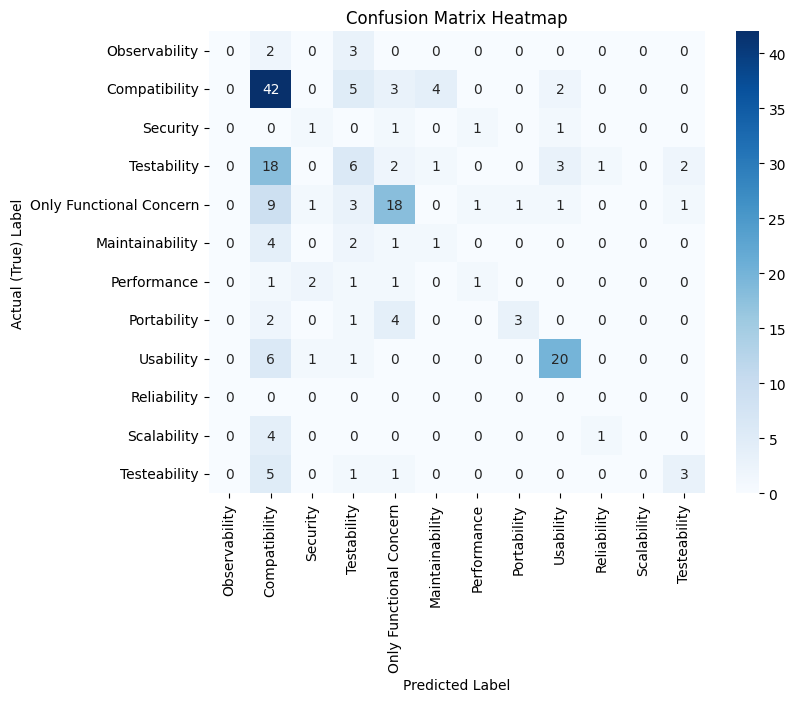

In [61]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(output_dict['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.show()

---

In [62]:
example_adr = list(adrs_to_classify.values())[2]
result = classifier.classify(example_adr) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(example_adr))


{
    "framework": "quality_attributes",
    "primary_category": "Maintainability",
    "explanation": "The decision to use Rollup for building distributables emphasizes simplifying the build process and maintaining the codebase efficiently. It focuses on ease of modification, configuration, and distribution, which are aspects of maintainability.",
    "primary_score": 0.8,
    "alternative_categories": [
        "Performance",
        "Portability"
    ],
    "alternative_confidence_scores": [
        0.1,
        0.1
    ]
}


# 3. Use Rollup to build distributables

Date: 2019-10-29

## Status

Accepted

## Context

We want to be able to distribute this library to me ingested by TypeScript or
plain JavaScript (both commonJS and module) applications.

[Rollup](https://rollupjs.org/guide/en/) is a popular JavaScript bundler with
support for TypeScript and simple configuration.

## Decision

We will build distributables using Rollup.js.

## Consequences

With Rollup.js we can build type declarations, commonJS, and module code using a
single simple command, and some simple config. This makes it easier for us to
distribute our code.


In [63]:
# results = classifier.classify_batch(adrs_to_classify, parallel=True, project='remultiform', organization='LBHackney-IT')
# results

In [64]:
# ADRClassifier.save_results(results, 'classification_results.json')

---